In [ ]:
import os
import torch
import matplotlib.pyplot as plt

from src.concaves.log import LogConcave

from src.distributions.stars.ellipsoid.multimodal.data_enclosing import MultimodalDataEnclosingEllipsoidStarDistribution

from src.diffeomorphisms.composition import CompositionDiffeomorphism
from src.diffeomorphisms.vector.concave import ConcaveVectorDiffeomorphism
from src.diffeomorphisms.vector.star import StarVectorDiffeomorphism

from archetypes import AA

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

# results folder
results_folder = os.path.join("results", "tree")
os.makedirs(results_folder, exist_ok=True)

# change font size of all plots
plt.rcParams.update({'font.size': 16})
markers = ['^', 'X', 'd', '*']

# set random seed
torch.manual_seed(31)

Using NumPy backend


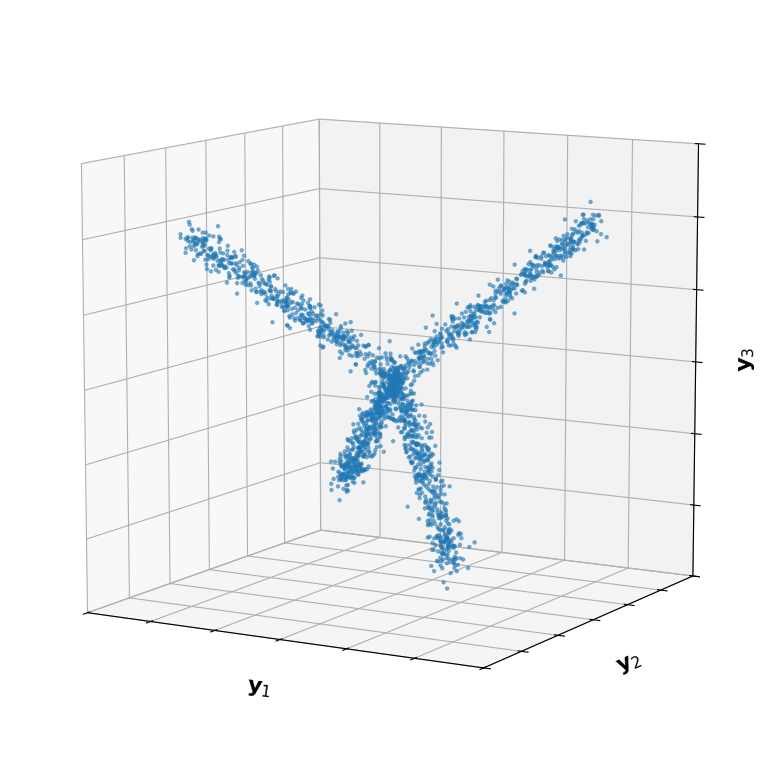

In [2]:
# construct data set from the four corners of a tetrahedron in R3
# construct tetrahedron corners
data_clusters = torch.tensor([[1.0, 1.0, 1.0],
                              [1.0, -1.0, -1.0],
                              [-1.0, 1.0, -1.0],
                              [-1.0, -1.0, 1.0]])

# generate data 
num_data_per_cluster = 500
sigma = 0.05
data = []
for center in data_clusters:
    for _ in range(num_data_per_cluster):
        t = torch.rand(1)
        point = t * center + (1 - t) * torch.zeros(3)
        point += sigma * torch.randn(3)  # small Gaussian noise
        data.append(point)
data = torch.stack(data)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], s=5, alpha=0.5)
# ax.scatter(data[:, 0], data[:, 1], -1.5 * torch.ones_like(data[:, 2]),
#            s=5, alpha=0.01, color=plt.cm.tab10(0))
# ax.scatter(data[:, 0], 1.5 * torch.ones_like(data[:, 1]), data[:, 2],
#            s=5, alpha=0.01, color=plt.cm.tab10(0))
# ax.scatter(-1.5 * torch.ones_like(data[:, 0]), data[:, 1], data[:, 2],
#            s=5, alpha=0.01, color=plt.cm.tab10(0))
ax.set_xlabel(r'$\mathbf{y}_1$')
ax.set_ylabel(r'$\mathbf{y}_2$')
ax.set_zlabel(r'$\mathbf{y}_3$')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_box_aspect([1, 1, 1])
ax.set_position([0.02, 0.02, 0.96, 0.94])
ax.view_init(elev=10)
fig.savefig(os.path.join(results_folder, "data.png"), bbox_inches='tight')
plt.show()

## Learn Star ##

In [3]:
aa = AA(4, init='furthest_sum')
aa.fit(data)
labels = torch.unique(torch.tensor(aa.labels_))

# construct centers
centers = []
for label in labels:
    centers.append(data[torch.tensor(aa.labels_) == label].mean(dim=0))

archetypes = torch.stack([archetype for archetype in torch.from_numpy(aa.archetypes_).to(data.dtype)])
labeled_data = [data[torch.tensor(aa.labels_) == label] for label in labels]

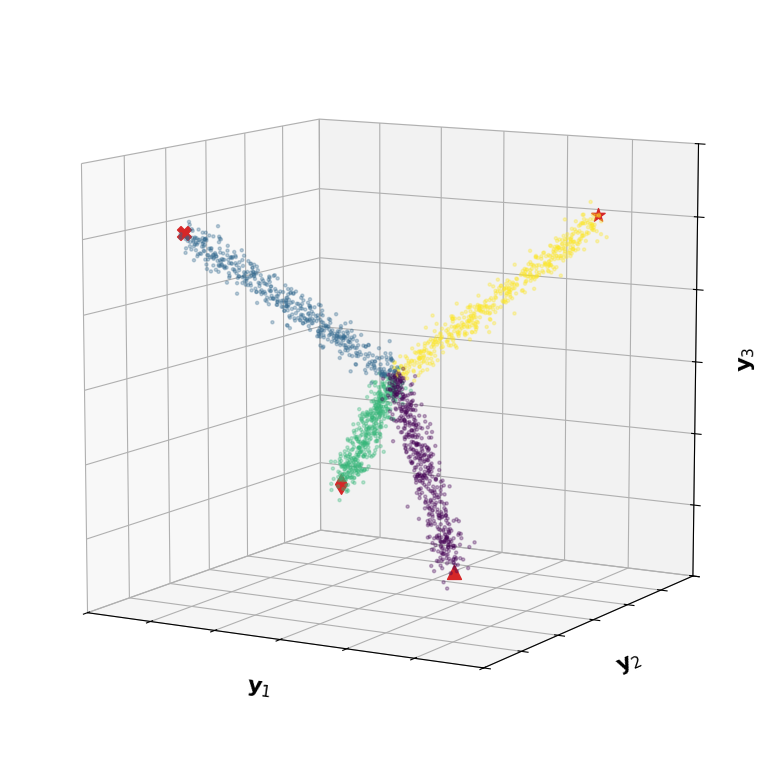

In [4]:
# plot data in 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], c=aa.labels_, s=5, alpha=0.3)
for i in range(4):
    ax.scatter(archetypes[i, 0], archetypes[i, 1], archetypes[i, 2], s=100, color=plt.cm.tab10(3), marker=markers[i])
ax.set_xlabel(r'$\mathbf{y}_1$')
ax.set_ylabel(r'$\mathbf{y}_2$')
ax.set_zlabel(r'$\mathbf{y}_3$')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_box_aspect([1, 1, 1])
ax.set_position([0.02, 0.02, 0.96, 0.94])
ax.view_init(elev=10)
fig.savefig(os.path.join(results_folder, "labeled_data.png"), bbox_inches='tight')
plt.show()

In [5]:
star = MultimodalDataEnclosingEllipsoidStarDistribution(labeled_data, centers, beta=1e-2)

In [6]:
chi = StarVectorDiffeomorphism(3, star)
psi = ConcaveVectorDiffeomorphism(3, LogConcave(a=5.))
Omega = CompositionDiffeomorphism([chi, psi])

chi_manifold = StandardPullbackVectorEuclidean(chi)
Omega_manifold = StandardPullbackVectorEuclidean(Omega)

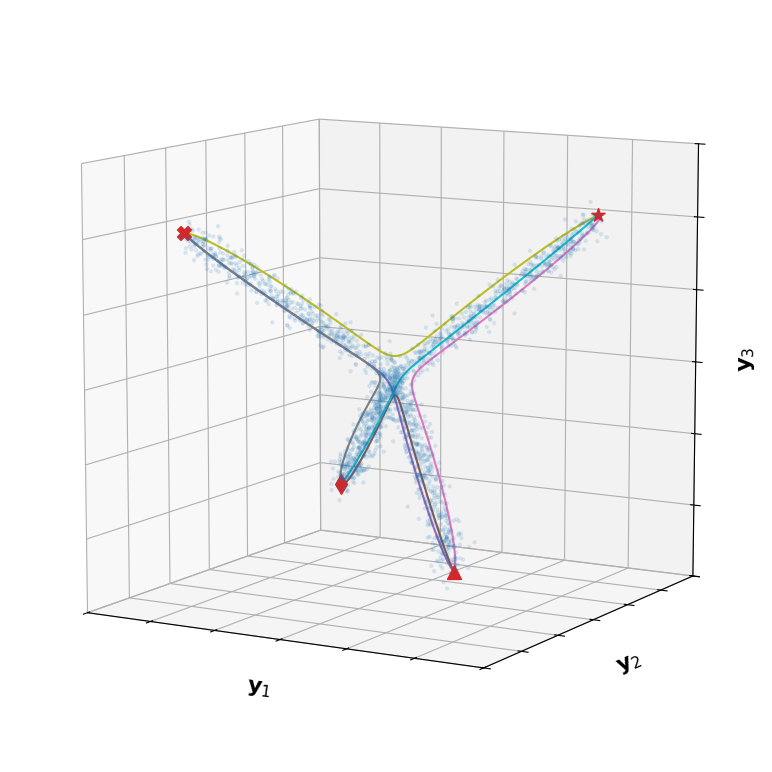

In [7]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    chi_geodesics = chi_manifold.geodesic(archetypes[None], archetypes[None], t)[0]

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(4):
    ax.scatter(archetypes[i, 0], archetypes[i, 1], archetypes[i, 2], s=100, color=plt.cm.tab10(3), marker=markers[i])
k = 4
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(chi_geodesics[i, j, :, 0].numpy(), chi_geodesics[i, j, :, 1].numpy(), chi_geodesics[i, j, :, 2].numpy(), color=plt.cm.tab10(k), label=f'Geodesic {i}-{j}')
        k+=1
ax.set_xlabel(r'$\mathbf{y}_1$')
ax.set_ylabel(r'$\mathbf{y}_2$')
ax.set_zlabel(r'$\mathbf{y}_3$')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_box_aspect([1, 1, 1])
ax.set_position([0.02, 0.02, 0.96, 0.94])
ax.view_init(elev=10)
plt.savefig(os.path.join(results_folder,"data_chi_geodesics.png"), bbox_inches='tight')
plt.show()

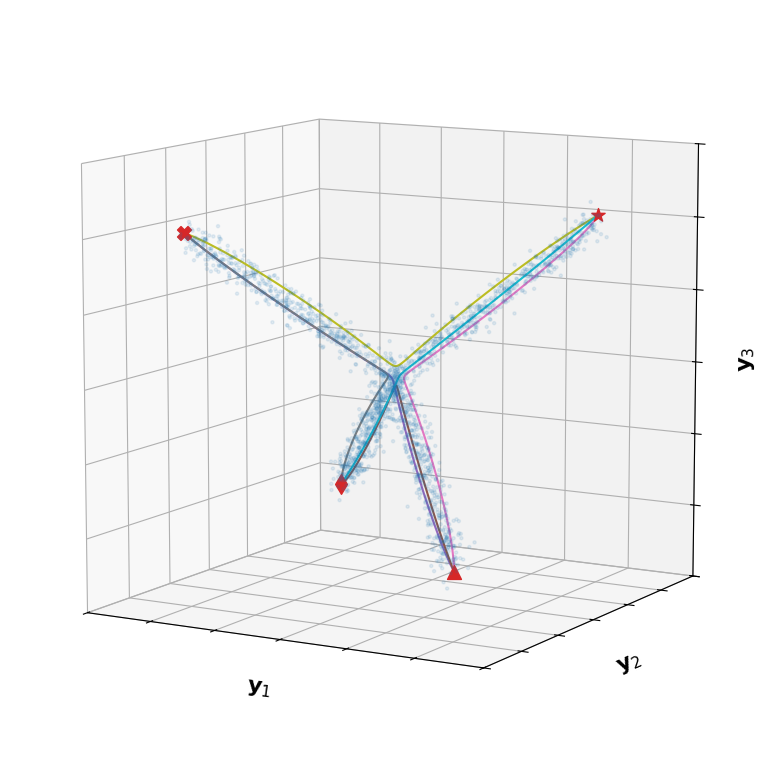

In [8]:
# compute geodesics between all pairs of points
t = torch.linspace(0, 1, steps=100)
with torch.no_grad():
    Omega_geodesics = Omega_manifold.geodesic(archetypes[None], archetypes[None], t)[0]

# plot geodesics
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
# plot data points
ax.scatter(data[:, 0].numpy(), data[:, 1].numpy(), data[:, 2].numpy(), s=5, alpha=0.1, label='Original Data')
for i in range(4):
    ax.scatter(archetypes[i, 0], archetypes[i, 1], archetypes[i, 2], s=100, color=plt.cm.tab10(3), marker=markers[i])
k = 4
for i in range(data_clusters.shape[0]): 
    for j in range(i + 1, data_clusters.shape[0]):
        ax.plot(Omega_geodesics[i, j, :, 0].numpy(), Omega_geodesics[i, j, :, 1].numpy(), Omega_geodesics[i, j, :, 2].numpy(), color=plt.cm.tab10(k), label=f'Geodesic {i}-{j}')
        k+=1
ax.set_xlabel(r'$\mathbf{y}_1$')
ax.set_ylabel(r'$\mathbf{y}_2$')
ax.set_zlabel(r'$\mathbf{y}_3$')
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)
ax.set_box_aspect([1, 1, 1])
ax.set_position([0.02, 0.02, 0.96, 0.94])
ax.view_init(elev=10)
plt.savefig(os.path.join(results_folder,"data_Omega_geodesics.png"), bbox_inches='tight')
plt.show()